<a href="https://colab.research.google.com/github/Watcharaphong09/week6-ANN-MNIST-Deploy-67102010174/blob/main/Intro-ANN-MNIST-67102010174.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab: Intro. ANN, MNIST Model + Deploy with Streamlit

- รหัสนิสิต: 67102010174
- ชื่อ - นามสกุล: นายวัชรพงศ์ มาลัง


- Google sheet link: https://docs.google.com/spreadsheets/d/1BHw4WhmwJAYRmXCtsbq00YODmssfhJqjghRKug22YDw/edit?usp=sharing
- GitHub Repo link: https://github.com/Watcharaphong09/week6-ANN-MNIST-Deploy-67102010174
- Your MNIST App: https://week6-ann-mnist-deploy-67102010174.streamlit.app


ส่งเป็น link folder week6-ANN-MNIST-Deploy-67102010174 ที่ประกอบด้วย
- Intro-ANN-MNIST-67102010174.ipynb
- app.py
- 67102010174_mnist_model.keras
- requirements.txt


### 0. Create venv & Install packages (กรณีที่จะทำบนเครื่องตนเอง)

VS Code --> Terminal > New Terminal

python -m venv ann-venv

ann-venv\Scripts\activate

pip list

pip install ipykernel

pip install tensorflow scikit-learn pandas matplotlib joblib

### 0. Mount Deive

ปรับ path ตามของตนเอง

In [1]:
# สำหรับรันบน Google Colab: ทำการ Mount Google Drive (หากต้องการบันทึกไฟล์ลง Drive)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted successfully.')
except ImportError:
    print('Running locally (ไม่ได้รันบน Colab), ข้ามขั้นตอนการ Mount Drive.')
except Exception as e:
    print(f'Drive Mount Status: {e}')


Running locally (ไม่ได้รันบน Colab), ข้ามขั้นตอนการ Mount Drive.


In [2]:
# ปรับ path ตามของตนเองบน Google Drive เช่น:
# %cd /content/drive/MyDrive/week6-ANN-MNIST-Deploy-67102010174
import os
print('Current Working Directory:', os.getcwd())


Current Working Directory: c:\Users\Watcharaphong\Desktop\SWU\CP461\week6


In [3]:
import os
print('Files in current directory:', os.listdir('.'))


Files in current directory: ['67102010174_mnist_model.keras', 'ann-venv', 'app.py', 'img_1.jpg', 'Intro-ANN-MNIST-67102010174.ipynb', 'Intro-ANN-MNIST-std.ipynb', 'requirements.txt', 'RubricsLabNN.pdf', 'week6-ANN-MNIST-Deploy-67102010174', '__pycache__']


### 1. Import TensorFlow and Keras:

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'Using GPU: {gpus}')
else:
    print('Running on CPU')


TensorFlow version: 2.21.0


Running on CPU


### 2. Load and Prepare Data (MNIST):

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [6]:
x_test.shape, y_test.shape

((10000, 28, 28), (10000,))

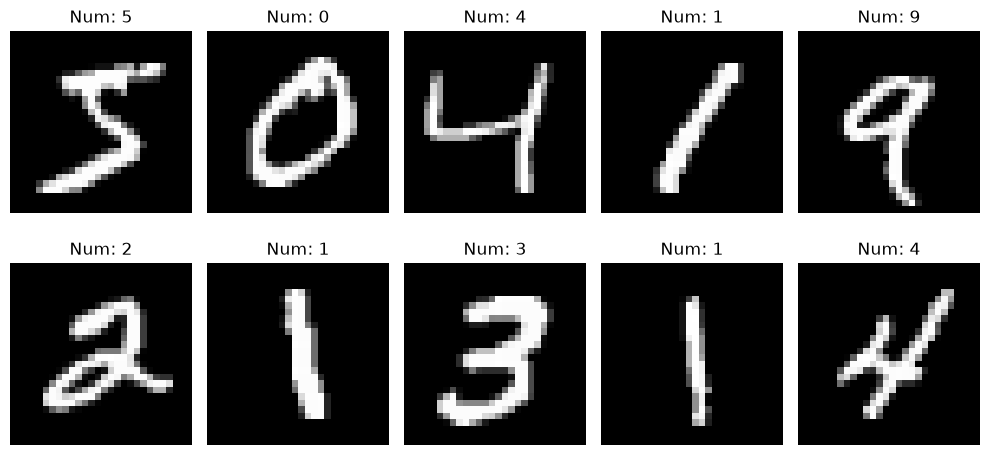

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Num: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### 3. Define the Model Architecture (Sequential API):

In [8]:

model = keras.Sequential([
	# Flatten 28x28 image to 784-element vector
	keras.Input(shape=(28, 28)),
	layers.Flatten(),

	# Hidden Layer 1: 128 neurons, ReLU activation
	layers.Dense(128, activation="relu"),

	# Output Layer: 10 neurons, Softmax activation
	layers.Dense(10, activation="softmax")
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Compile the Model:

In [10]:
model.compile(
	optimizer="adam",
	loss="sparse_categorical_crossentropy",
	metrics=["accuracy"]
)

### 5. Train the Model (the \texttt{fit} function):

In [11]:
history = model.fit(
		x_train,
		y_train,
		epochs=5,
		batch_size=32,
		validation_split=0.2
)

Epoch 1/5


   1/1500 ━━━━━━━━━━━━━━━━━━━━ 59:08 2s/step - accuracy: 0.0938 - loss: 2.4020

   9/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3438 - loss: 2.0492  

  18/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4983 - loss: 1.7826

  27/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5567 - loss: 1.5797

...

1463/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9849 - loss: 0.0496

1473/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9849 - loss: 0.0496

1483/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.0495

1493/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9849 - loss: 0.0496

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9757 - val_loss: 0.0862


### 6. Evaluate the Model:

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc}")

313/313 - 2s - 6ms/step - accuracy: 0.9750 - loss: 0.0792



Test accuracy: 0.9750000238418579


### 7. Plot Training History:

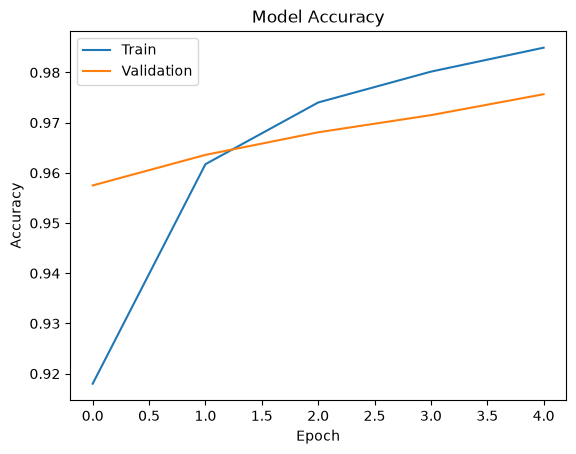

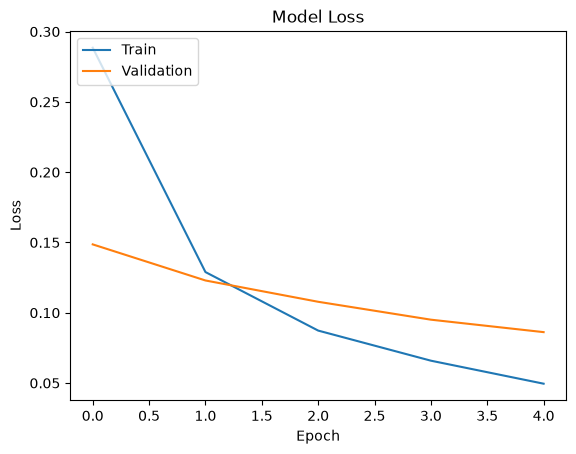

In [13]:
import matplotlib.pyplot as plt
# Plot accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plot loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 8. Detailed Evaluation: Confusion Matrix and Classification Report

In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions = model.predict(x_test)
# Convert predictions from probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

  1/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step

 17/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

 35/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 53/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 71/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...

293/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step



Confusion Matrix:
[[ 966    0    1    1    2    4    2    1    2    1]
 [   0 1122    4    1    0    1    3    1    3    0]
 [   4    0  994   13    4    0    1    9    6    1]
 [   1    0    6  991    0    4    0    2    6    0]
 [   0    0    4    0  956    0    1    4    0   17]
 [   2    0    0   13    1  862    4    3    5    2]
 [   3    3    1    1    5    6  937    0    2    0]
 [   1    5    8    1    0    0    0 1008    2    3]
 [   3    0    2    9    5    4    3    4  940    4]
 [   3    4    0    7    6    5    0    7    3  974]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.97      0.97       892
           6       0.99      0.98      0.98    

In [15]:
cm = confusion_matrix(y_test, y_pred)


**prompt:** plot confusion matrix

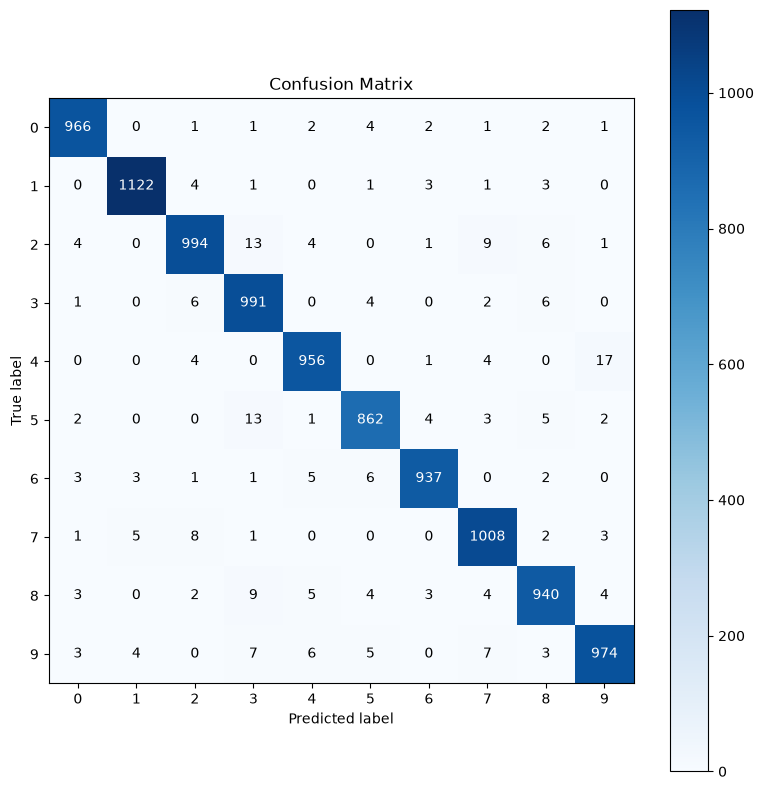

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(cm.shape[0])
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Annotate each cell with the count
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

### View Mnist Data

**prompt:** plot mnist data

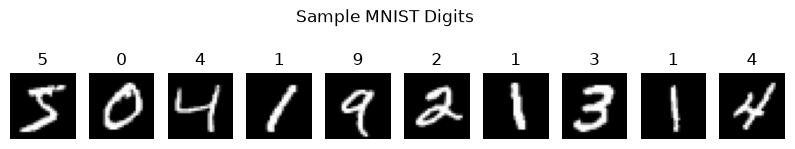

In [17]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample MNIST Digits')
plt.show()

**prompt:** plot x_test and print predicted results

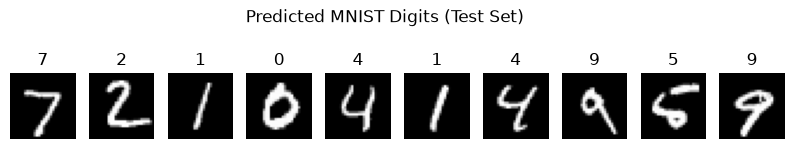

Predicted labels for first 10 test images: [7 2 1 0 4 1 4 9 5 9]


In [18]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(str(y_pred[i]))
    plt.axis('off')
plt.suptitle('Predicted MNIST Digits (Test Set)')
plt.show()
print("Predicted labels for first 10 test images:", y_pred[:10])

## Save Model

In [19]:
# Save the model in the native Keras format
model.save('67102010174_mnist_model.keras')
print("Model saved to mnist_model.keras")


Model saved to mnist_model.keras


## Restart Kernel/Session

## Load Model, Read Image and Predict

https://www.kaggle.com/datasets/scolianni/mnistasjpg

In [20]:
import os
print('Files in current directory:', os.listdir('.'))


Files in current directory: ['67102010174_mnist_model.keras', 'ann-venv', 'app.py', 'img_1.jpg', 'Intro-ANN-MNIST-67102010174.ipynb', 'Intro-ANN-MNIST-std.ipynb', 'requirements.txt', 'RubricsLabNN.pdf', 'week6-ANN-MNIST-Deploy-67102010174', '__pycache__']


In [21]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model('67102010174_mnist_model.keras')
print("Model loaded successfully!")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


The model predicts the digit is: 2


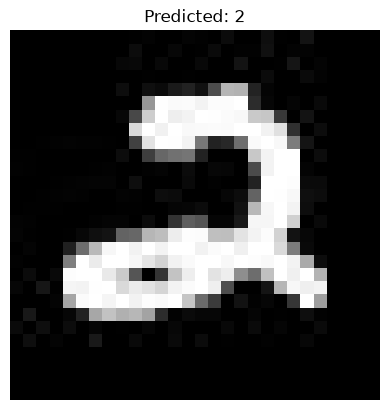

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# 1. Define the path to your image file
image_path = 'img_1.jpg'

# กรณีรันบน Colab แล้วยังไม่มีไฟล์ img_1.jpg ให้ดาวน์โหลดจาก GitHub ให้อัตโนมัติ
if not os.path.exists(image_path):
    github_img_url = 'https://raw.githubusercontent.com/Watcharaphong09/week6-ANN-MNIST-Deploy-67102010174/main/img_1.jpg'
    try:
        print(f'กำลังดาวน์โหลด {image_path} จาก GitHub Repo...')
        urllib.request.urlretrieve(github_img_url, image_path)
        print(f'ดาวน์โหลด {image_path} สำเร็จ!')
    except Exception as e:
        print(f'ไม่สามารถดาวน์โหลดอัตโนมัติได้: {e}')

try:
    # 2. Load the image using Pillow (PIL)
    img = Image.open(image_path)

    # 3. Convert the image to grayscale (MNIST images are grayscale)
    img = img.convert('L')

    # 4. Resize the image to 28x28 pixels, as required by the MNIST model
    img = img.resize((28, 28))

    # 5. Convert the image into a NumPy array
    img_array = np.array(img)

    # 6. Normalize the pixel values from [0, 255] to [0, 1]
    img_array = img_array.astype('float32') / 255.0

    # 7. Reshape the array to add a batch dimension (1 image, 28x28 pixels)
    # Our model expects input in the shape (batch_size, 28, 28)
    img_array = img_array.reshape(1, 28, 28)

    # 8. Use the trained model to make a prediction
    # The model outputs probabilities for each of the 10 digits
    prediction = model.predict(img_array)

    # 9. Get the predicted digit by finding the index of the highest probability
    predicted_digit = np.argmax(prediction)

    print(f'The model predicts the digit is: {predicted_digit}')

    # 10. Display the image with the predicted digit
    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted: {predicted_digit}')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: The image file '{image_path}' was not found. Please upload 'img_1.jpg' to your environment.")
except Exception as e:
    print(f'An unexpected error occurred: {e}. Please check the image format or content.')


## Create app.py - Streamlit

In [23]:
%%writefile app.py
import streamlit as st
from PIL import Image
import numpy as np
import tensorflow as tf
import os

st.set_page_config(page_title='MNIST Digit Predictor - 67102010174', page_icon='🔢')
st.title('🔢 MNIST Digit Predictor')
st.caption('ผู้พัฒนา: นายวัชรพงศ์ มาลัง | รหัสนิสิต: 67102010174')
st.write('Upload an image of a handwritten digit to get a prediction.')

model_path = '67102010174_mnist_model.keras'
if not os.path.exists(model_path):
    st.error(f"Model file '{model_path}' not found. Please ensure the model is saved correctly.")
else:
    model = tf.keras.models.load_model(model_path)

uploaded_file = st.file_uploader('Choose an image...', type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    try:
        img = Image.open(uploaded_file)
        st.image(img, caption='Uploaded Image', use_container_width=True)
        st.write('Classifying...')

        img = img.convert('L')
        img = img.resize((28, 28))
        img_array = np.array(img).astype('float32') / 255.0
        img_array = img_array.reshape(1, 28, 28)

        prediction = model.predict(img_array)
        predicted_digit = np.argmax(prediction)
        confidence = float(np.max(prediction)) * 100

        st.success(f'The model predicts the digit is: **{predicted_digit}** (Confidence: {confidence:.2f}%)')
        st.bar_chart(prediction[0])
    except Exception as e:
        st.error(f'An error occurred during prediction: {e}')


Overwriting app.py


In [24]:
%%writefile requirements.txt
streamlit
Pillow
tensorflow
rich>=10.14.0


Overwriting requirements.txt


In [25]:
import sys
print('Python version:', sys.version)


Python version: 3.11.16 (main, Sep 24 2026, 17:55:08) [MSC v.1944 64 bit (AMD64)]


## Deployment

**ไปที่  https://github.com**

1.  สร้าง GitHub Repository

2. อัพโหลดไฟล์ใน GitHub Repository
ตรวจสอบให้แน่ใจว่าใน Repo ของคุณมีไฟล์ครบ 3 ไฟล์หลัก:

- app.py: ไฟล์โค้ดหน้าเว็บ Streamlit

- 6xxxx_mnist_model.keras: ไฟล์ Model ที่ Save ไว้

- requirements.txt: ไฟล์ระบุ Library ที่ต้องใช้ (เพื่อให้ Server ติดตั้ง Environment ได้ถูกต้อง)


**ไปที่ https://share.streamlit.io**

1. Sign in with GitHub เพื่อเชื่อมต่อบัญชี

2. คลิกปุ่ม "Create app" (หรือ "New app")

3. กรอกรายละเอียดดังนี้:

- Repository: เลือกชื่อ Repo ที่เพิ่งสร้าง

- Branch: ปกติจะเป็น main หรือ master

- Main file path: พิมพ์ app.py

4. คลิกปุ่ม "Deploy!"



**Problem Fix**

**ตรวจสอบสถานะการทำงาน** -->
สังเกตสถานะการ Deploy ที่มุมขวาล่าง (Manage app)


การจัดการ Python Version และการ Reboot
หากตรวจสอบ Logs แล้วพบว่า Library บางตัวติดตั้งไม่ผ่าน หรือ Code รันไม่ได้เนื่องจากความต่างของเวอร์ชัน ให้ลองใช้วิธีดังนี้:

**A. การเปลี่ยน Python Version (Advanced Settings)**
Streamlit Cloud มักจะใช้ Python เวอร์ชันล่าสุดเป็นค่าเริ่มต้น แต่หาก Model ของเราเทรนมาด้วยเวอร์ชันที่เก่ากว่า (เช่น Python 3.11 หรือ 3.12) เราสามารถปรับเปลี่ยนได้ที่:

- ในหน้า Dashboard ของ Streamlit ให้คลิกที่จุด 3 จุด (⋮) ข้างชื่อ App ของเรา

- เลือก Settings > Python Version

- เลือกเวอร์ชันที่ตรงกับเครื่องที่เราใช้เทรน (แนะนำ 3.10 หรือ 3.11 สำหรับเสถียรภาพสูงสุดกับ TensorFlow) ในงานนี้อาจลอง 3.12

- กด Save ระบบจะทำการลบ Environment เก่าและสร้างใหม่ให้ทันที

**B. การ Reboot App (ล้างไพ่ใหม่)**
- ในบางครั้งหลังจากเราแก้ไฟล์ requirements.txt บน GitHub แล้ว แต่ Server ยังจำค่าเดิมหรือค้าง (Cache) อยู่:

- ให้ไปที่เมนู Manage app (มุมขวาล่าง)

- คลิกจุด 3 จุดด้านบนของแถบ Logs แล้วเลือก Reboot app

- การ Reboot จะช่วยบังคับให้ Streamlit ติดตั้งทุกอย่างใหม่ตั้งแต่ต้น (Clean Install)



**ปรับแต่ง App**

- https://docs.streamlit.io/develop

- https://streamlit.io/gallery
